In [151]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [152]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

(50000, 32, 32, 3)

In [153]:
X_test.shape

(10000, 32, 32, 3)

In [154]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [155]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [156]:
classes = ["airplane", "automobile", "bird","cat","deer", "dog", "frog", "horse", "ship", "truck"]

In [157]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.X_label(classes[y[index]])

AttributeError: module 'matplotlib.pyplot' has no attribute 'X_label'

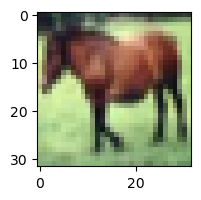

In [158]:
plot_sample(X_train, y_train, 7)

In [ ]:
X_train = X_train/255
X_test = X_test / 255 

In [ ]:
ann = models.Sequential([
       layers.Flatten(input_shape=(32,32,3)),
       layers.Dense(3000, activation='relu'),
       layers.Dense(1000, activation='relu'),
       layers.Dense(10, activation='sigmoid')
  ])
ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=5)

In [ ]:
ann.evaluate(X_test, y_test)

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

In [ ]:
cnn = models.Sequential([
    #cnn
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    #dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation= 'softmax')
])


In [ ]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

In [ ]:
cnn.evaluate(X_test, y_test)

In [ ]:
y_test = y_test.reshape(-1,)
y_test[:5]

In [ ]:
plot_sample(X_test, y_test, 6)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

In [ ]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:7]

In [ ]:
y_test[:7]

In [ ]:
plot_sample(X_test, y_test,0)

In [ ]:
classes[y_classes[0]]

In [ ]:
print("Classification Report: \n", classification_report(y_test, y_classes))